In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Load data
df = pd.read_csv(r"/Users/puravpatel/Documents/Programming/Spatio-Temporal-Graph-Neural-Networks/backend/data/Processed Data/climate_data.csv")

# Group by unique coordinates
locations = df.groupby(['latitude', 'longitude'])

# Normalize rainfall and temperature
scaler = MinMaxScaler()
df[['rainfall', 'temperature']] = scaler.fit_transform(df[['rainfall', 'temperature']])

# Build time series data for each location
sequences = []
for (lat, lon), group in locations:
    group_sorted = group.sort_values('year')
    sequence = group_sorted[['rainfall', 'temperature']].values
    if sequence.shape[0] == 44:  # Ensure all years present (1980–2023)
        sequences.append(sequence)

data = np.array(sequences)  # shape: [num_locations, 44, 2]

print(data.shape)  # Should be (N, 44, 2)


(5040, 44, 2)


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


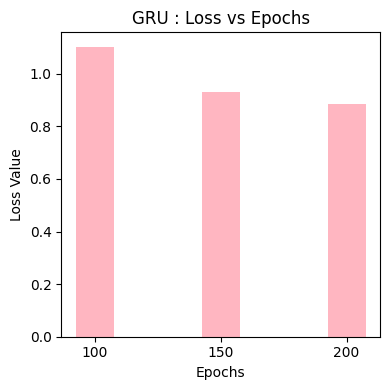

In [33]:
import matplotlib.pyplot as plt

# Data
df = [1.1023,
0.9317,
0.8860
]
df1 = [100, 150, 200]

# Create bar plot
plt.figure(figsize=(4, 4))
plt.bar(df1, df, width=15, color='lightpink')

# Add labels and title
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.title("GRU : Loss vs Epochs")
plt.xticks(df1)

# Show plot
plt.tight_layout()
plt.show()


In [6]:
import torch.nn as nn

class SimpleGRU(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super(SimpleGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out)


In [8]:
model = SimpleGRU()
loss_fn = MixedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(101):
    total_loss = 0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 7.6906
Epoch 11, Loss: 2.6714
Epoch 21, Loss: 1.9095
Epoch 31, Loss: 1.6188
Epoch 41, Loss: 1.4577
Epoch 51, Loss: 1.3528
Epoch 61, Loss: 1.2793
Epoch 71, Loss: 1.2163
Epoch 81, Loss: 1.1709
Epoch 91, Loss: 1.1370
Epoch 101, Loss: 1.1023
